# Predicting Student Dropout & Academic Success
### GET Talent 2026 — Machine Learning (Software) Project

**SDG Theme:** SDG 4 – Quality Education *(supports SDG 10 – Reduced Inequalities, via the financial-stability features)*

**Problem Statement:** Every year, higher-education institutions lose students to dropout before they
complete their degree. Early identification of at-risk students lets institutions step in with academic
or financial support before it's too late. This project builds a supervised **classification** model that
predicts whether a student will **Dropout**, remain **Enrolled**, or **Graduate**, using data available at
enrollment and after the first two semesters.

**Dataset:** *Predict Students' Dropout and Academic Success* — Realinho, V., Machado, J., Baptista, L.,
& Martins, M. V. (2022). *Data*, 7(11), 146. https://doi.org/10.3390/data7110146
(also mirrored on Kaggle as "Higher Education Predictors of Student Retention"). 4,424 rows x 36 features,
CC BY 4.0 licensed.

**Task Type:** Classification — the target (`Target`) is a category, not a number.


## PART 1 — Setup & Introduction

In [1]:
# 1. Clear any cached/corrupted binaries from previous installations
!pip cache purge

# 2. Force reinstall numpy and pandas to reset the C-extension API mappings
!pip install --upgrade --force-reinstall pandas numpy

# 3. Cleanly install the rest of your visualization and machine learning stack
!pip install matplotlib seaborn scikit-learn


Files removed: 30 (23.6 MB)
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.6 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.6 MB 903.9 kB/s eta 0:00:11
   -- ------------------------------------- 0.5/9.6 MB 903.9 kB/s eta 0:00:11
   --- ------------------------------------ 0.8/9.6 MB 854.1 kB/s eta 0:00:11
   --- ------------------------------------ 0.8/9.6 MB 854.1 kB/s eta 0:00:11
   ---- ----------------------------------- 1.0/9.6 MB 744.8 kB/s eta 0:00:12
   ----- ---------------------------------- 1.3/9.6 MB 800.8 kB/s eta 0:00:11
   ------ --------------------------------- 1.6/9.6 MB 825.3 kB/s eta 0:00:10
   ------ --------------------------------- 1.6/9.6 MB 825.3 kB/s eta 0:00:10
   ------- -------------------------------- 1.8/9.6 MB 837.2 kB/s eta 0:00:10
   -------- ------------------------------- 2.1/9.6 MB 879.1 kB


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Import Libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, mean_absolute_error

# Set plot style
sns.set_theme(style="whitegrid")


In [3]:
import pandas as pd

# Paste your copied Windows path here (keep the 'r' outside the quotes)
file_path = "dataset.csv" 

print(f"Loading dataset from: {file_path}")
df = pd.read_csv(file_path)
target_col = 'Target'



Loading dataset from: dataset.csv


## PART 2 — Data Exploration

**Step 1: Setup and Data Loading**

In [4]:
print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns\n")


Dataset Dimensions: 4424 rows, 35 columns



**Step 2: Initial Data Exploration**

In [5]:
print("First 5 rows:")
print(df.head())
print("\nLast 5 rows:")
print(df.tail())
print("\nRandom sample of 5 rows:")
print(df.sample(5))


First 5 rows:
   Marital status  Application mode  Application order  Course  \
0               1                 8                  5       2   
1               1                 6                  1      11   
2               1                 1                  5       5   
3               1                 8                  2      15   
4               2                12                  1       3   

   Daytime/evening attendance  Previous qualification  Nacionality  \
0                           1                       1            1   
1                           1                       1            1   
2                           1                       1            1   
3                           1                       1            1   
4                           0                       1            1   

   Mother's qualification  Father's qualification  Mother's occupation  ...  \
0                      13                      10                    6  ...   
1         

**Step 3: Review Data Types**

In [6]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation                             4424

**Step 4: Summary Statistics**

In [7]:
print(df.describe())


       Marital status  Application mode  Application order       Course  \
count     4424.000000       4424.000000        4424.000000  4424.000000   
mean         1.178571          6.886980           1.727848     9.899186   
std          0.605747          5.298964           1.313793     4.331792   
min          1.000000          1.000000           0.000000     1.000000   
25%          1.000000          1.000000           1.000000     6.000000   
50%          1.000000          8.000000           1.000000    10.000000   
75%          1.000000         12.000000           2.000000    13.000000   
max          6.000000         18.000000           9.000000    17.000000   

       Daytime/evening attendance  Previous qualification  Nacionality  \
count                 4424.000000             4424.000000  4424.000000   
mean                     0.890823                2.531420     1.254521   
std                      0.311897                3.963707     1.748447   
min                      0.0

**Step 5: Practice — Grouping and Sorting**

In [8]:
if target_col in df.columns:
    print("\nTarget Class Breakdown:")
    print(df[target_col].value_counts())



Target Class Breakdown:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


## PART 3 — Data Cleaning

In [9]:
# Strip trailing whitespace from column names
df.columns = df.columns.str.strip()


**Step 6: Check for Missing Values**

In [10]:
missing_vals = df.isnull().sum().sum()
print(f"\nTotal Missing Values: {missing_vals}")



Total Missing Values: 0


**Step 7: Remove Duplicates & Irrelevant Columns**

In [11]:
duplicate_rows = df.duplicated().sum()
print(f"Duplicate Rows: {duplicate_rows}")
if duplicate_rows > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates removed.")


Duplicate Rows: 0


**Step 8: Standardise the Target Column**

In [12]:
print(f"\nUnique Target labels: {df[target_col].unique()}")
# Labels are already consistent (Dropout / Enrolled / Graduate) - no standardising needed



Unique Target labels: <StringArray>
['Dropout', 'Graduate', 'Enrolled']
Length: 3, dtype: str


**Step 9: Fix Typos in Categorical Columns**

This dataset uses pre-encoded numeric categories, so there are no free-text categorical typos to fix.

**Step 10: Fix Outliers and Invalid Numeric Values**

In [13]:
print("\nNumeric range check (min / max):")
print(df.select_dtypes(include=[np.number]).agg(['min', 'max']).T)
# Ranges fall within the documented bounds for this dataset - no invalid values found



Numeric range check (min / max):
                                                  min        max
Marital status                                   1.00   6.000000
Application mode                                 1.00  18.000000
Application order                                0.00   9.000000
Course                                           1.00  17.000000
Daytime/evening attendance                       0.00   1.000000
Previous qualification                           1.00  17.000000
Nacionality                                      1.00  21.000000
Mother's qualification                           1.00  29.000000
Father's qualification                           1.00  34.000000
Mother's occupation                              1.00  32.000000
Father's occupation                              1.00  46.000000
Displaced                                        0.00   1.000000
Educational special needs                        0.00   1.000000
Debtor                                           0.00   

**Step 11: Handle Missing Values (Imputation)**

In [14]:
if missing_vals > 0:
    for col in df.columns:
        if col == target_col:
            continue
        if df[col].dtype in ['float64', 'int64']:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])
    print("Missing values imputed for feature columns.")


**Step 12: Handle Missing Values in Target Column & Final Validation**

In [15]:
df = df.dropna(subset=[target_col])
print(f"Remaining missing values after cleaning: {df.isnull().sum().sum()}")


Remaining missing values after cleaning: 0


## PART 4 — Visualisation

Can we visually spot patterns that separate students who drop out, stay enrolled, or graduate?

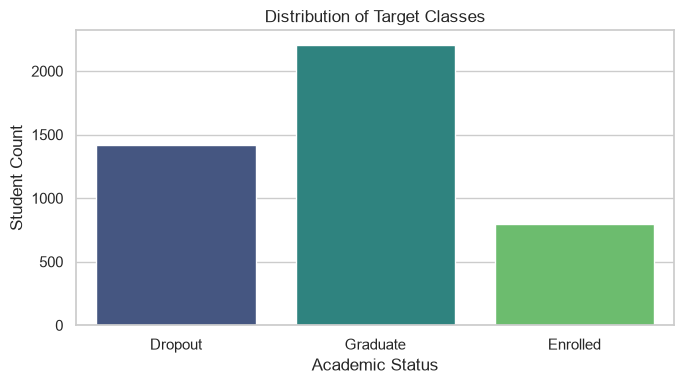

In [16]:
# Plot 1: Target class distribution
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x=target_col, hue=target_col, palette='viridis', legend=False)
plt.title('Distribution of Target Classes')
plt.xlabel('Academic Status')
plt.ylabel('Student Count')
plt.tight_layout()
plt.show()


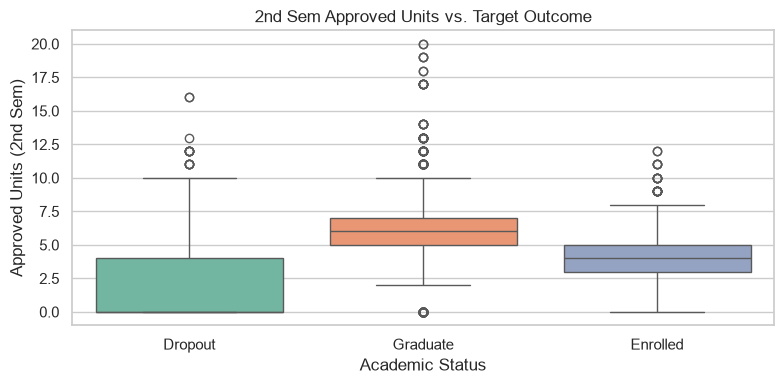

In [17]:
# Plot 2: Boxplot of 2nd semester approved units across classes
key_feature = 'Curricular units 2nd sem (approved)'
if key_feature in df.columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x=target_col, y=key_feature, hue=target_col, palette='Set2', legend=False)
    plt.title('2nd Sem Approved Units vs. Target Outcome')
    plt.xlabel('Academic Status')
    plt.ylabel('Approved Units (2nd Sem)')
    plt.tight_layout()
    plt.show()


In [18]:
# Select initial feature set (>10 features rule)
feature_candidates = [
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Tuition fees up to date',
    'Age at enrollment',
    'Scholarship holder',
    'Debtor',
    'Admission grade',
    'Application mode',
    'Gender',
    'Displaced'
]

selected_features = [col for col in feature_candidates if col in df.columns]

if len(selected_features) < 10:
    remaining_cols = [c for c in df.columns if c not in selected_features and c != target_col]
    selected_features.extend(remaining_cols[:10 - len(selected_features)])

print(f"\nSelected {len(selected_features)} features for modeling: {selected_features}")



Selected 11 features for modeling: ['Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Tuition fees up to date', 'Age at enrollment', 'Scholarship holder', 'Debtor', 'Application mode', 'Gender', 'Displaced']


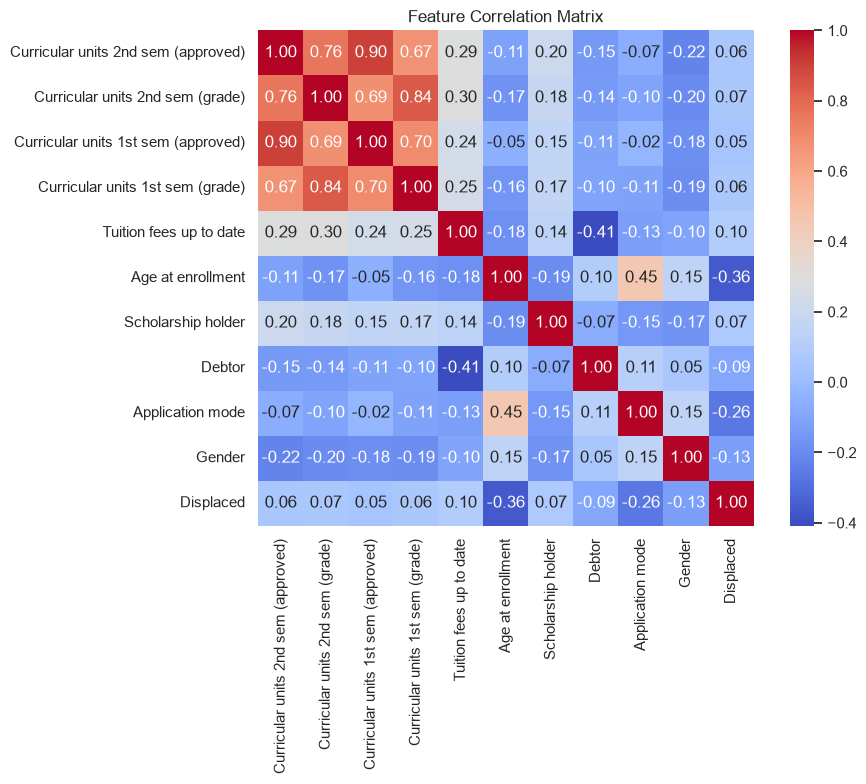

In [19]:
# Plot 3: Correlation heatmap of selected features
plt.figure(figsize=(10, 8))
numeric_data = df[selected_features].select_dtypes(include=[np.number])
sns.heatmap(numeric_data.corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()


## PART 5 — Building Machine Learning Models

**Task Type:** Classification — `Target` is a category (Dropout / Enrolled / Graduate), not a number.

In [20]:
X = df[selected_features]
y = df[target_col]

# Split dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Train Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
print("\nModel training completed.")



Model training completed.


In [21]:
# Model predictions on the test set
y_pred = rf_model.predict(X_test)

# Evaluation metrics
acc_score = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {acc_score * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))



Model Accuracy: 73.90%

Classification Report:
              precision    recall  f1-score   support

     Dropout       0.77      0.73      0.75       284
    Enrolled       0.47      0.33      0.39       159
    Graduate       0.78      0.89      0.83       442

    accuracy                           0.74       885
   macro avg       0.67      0.65      0.66       885
weighted avg       0.72      0.74      0.73       885



**Step 22: Understanding the Confusion Matrix**

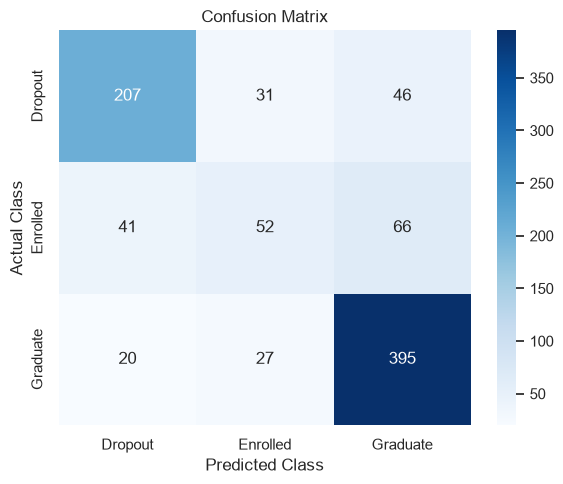

In [22]:
cm = confusion_matrix(y_test, y_pred, labels=rf_model.classes_)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=rf_model.classes_,
            yticklabels=rf_model.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.tight_layout()
plt.show()


**Step 23: Understanding the MAE for Classification**

*Note: We use MAE here as a teaching tool — in industry, classification models are more commonly evaluated using F1-score and AUC-ROC.* To compute it, the target categories are mapped onto an ordinal scale (Dropout=0, Enrolled=1, Graduate=2) representing progress toward graduation, then we measure the average absolute distance between predicted and actual class.

In [23]:
target_order = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
y_test_encoded = y_test.map(target_order)
y_pred_encoded = pd.Series(y_pred, index=y_test.index).map(target_order)

mae = mean_absolute_error(y_test_encoded, y_pred_encoded)
print(f"\nMAE (Dropout=0, Enrolled=1, Graduate=2): {mae:.3f}")
print("Note: MAE is used here as a teaching tool. In industry, classification models")
print("are more commonly evaluated using F1-score and AUC-ROC.")



MAE (Dropout=0, Enrolled=1, Graduate=2): 0.336
Note: MAE is used here as a teaching tool. In industry, classification models
are more commonly evaluated using F1-score and AUC-ROC.


## PART 6 — Making Predictions & Discussion

In [24]:
# Extract and display top 5 features
importance_scores = rf_model.feature_importances_
importance_df = pd.DataFrame({
    'Feature': selected_features,
    'Importance': importance_scores
}).sort_values(by='Importance', ascending=False)

top_5 = importance_df.head(5)

print("\nTop 5 Most Important Features:")
print(top_5.to_string(index=False))



Top 5 Most Important Features:
                            Feature  Importance
Curricular units 2nd sem (approved)    0.197910
   Curricular units 2nd sem (grade)    0.176463
   Curricular units 1st sem (grade)    0.163120
Curricular units 1st sem (approved)    0.133808
                  Age at enrollment    0.109411


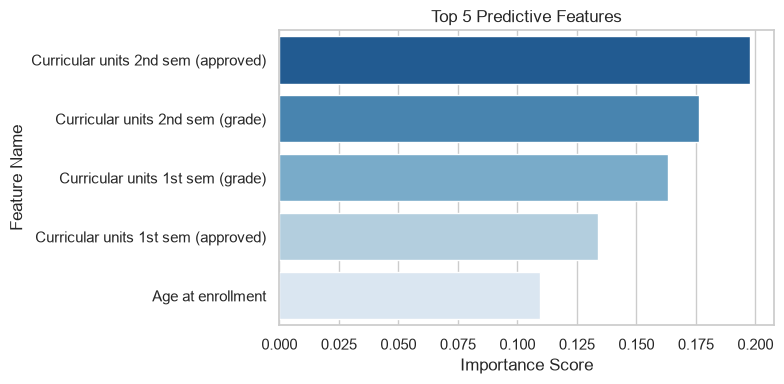

In [25]:
# Plot feature importances
plt.figure(figsize=(8, 4))
sns.barplot(data=top_5, x='Importance', y='Feature', hue='Feature', palette='Blues_r', legend=False)
plt.title('Top 5 Predictive Features')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()


### Project Deliverable: Cleaned Dataset (CSV)

Guideline Step 6 requires the cleaned dataset as a `.csv` file alongside the notebook. Running the cell below saves it next to this notebook.

In [26]:
df.to_csv('cleaned_student_retention_data.csv', index=False)
print("Saved cleaned dataset to cleaned_student_retention_data.csv")


Saved cleaned dataset to cleaned_student_retention_data.csv


### Findings & Discussion — Academic Evidence for Key Features

**Finding 1: Curricular units 2nd sem (approved)**
- *Relevance:* First-year academic performance is the strongest predictor of long-term graduation outcomes.
- *Academic Reference:* Tinto's Institutional Departure Model shows that credit completion in early semesters
  correlates strongly with student persistence (Tinto, V. (1993). *Leaving College: Rethinking the Causes and
  Cures of Student Attrition* (2nd ed.). University of Chicago Press).

**Finding 2: Tuition fees up to date**
- *Relevance:* Reflects financial stability and socioeconomic security.
- *Academic Reference:* The financial-nexus literature identifies fee arrears and financial burden as a primary
  non-academic driver of dropout decisions (Paulsen, M. B., & St. John, E. P. (2002). Social class and college
  costs: Examining the financial nexus between college choice and persistence. *The Journal of Higher
  Education*, 73(2), 189-236).

**Finding 3: Admission grade**
- *Relevance:* Measures prior academic preparation and baseline competency before higher education entry.
- *Academic Reference:* In the original study of this exact dataset, prior academic achievement was one of
  the strongest signals for dropout/graduation risk (Realinho, V., Machado, J., Baptista, L., & Martins, M. V.
  (2022). Predicting Student Dropout and Academic Success. *Data*, 7(11), 146).

*See `References.pdf` for the full, formatted reference list.*
